In [13]:
import warnings
warnings.filterwarnings('ignore')
import pandas as pd
import numpy as np
import os
from ydata_profiling import ProfileReport
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from datetime import datetime

### Read Data

In [14]:
BASE_PATH = os.path.abspath('..\data')
df = pd.read_csv(os.path.join(BASE_PATH, 'silver', 'joined_purchases.csv'))
df['date'] = df['date'].apply(
    lambda x: datetime.strptime(str(x), '%Y-%m-%d')
)
df.head()

,date,company_id,productcategory,quantity,revenue,unemployment_rate,gdp_value,cpi,mortgage_rate_30y,company_name,location,company_type,employees
0,2020-01-31,1.0,Appliances,144.0,4725.13,3.5,21481.367,257.971,3.51,Adams-Rice,Douglastown,public,"500-1,000"
1,2020-01-31,7.0,Fitness & Health,56.0,1701.78,3.5,21481.367,257.971,3.51,Ryan PLC,Lake Nicole,private,1-10
2,2020-01-31,7.0,Footwear,44.0,1407.84,3.5,21481.367,257.971,3.51,Ryan PLC,Lake Nicole,private,1-10
3,2020-01-31,7.0,Gaming,0.0,0.00,3.5,21481.367,257.971,3.51,Ryan PLC,Lake Nicole,private,1-10
4,2020-01-31,7.0,Home & Kitchen,0.0,0.00,3.5,21481.367,257.971,3.51,Ryan PLC,Lake Nicole,private,1-10


### Explore Data with Pandas Profiling

In [3]:
profile = ProfileReport(df, title='Purchasing Analysis')
profile.to_file(
    os.path.join(BASE_PATH, 'silver', 'purchase_analysis.html')
)

Export report to file: 100%|██████████| 1/1 [00:00<00:00, 53.50it/s]


### Remove ID's and names & Aggregate on a monthly basis

In [15]:
# We also remove here the revenue since it can be deduced directly from quantity

df.drop(
    ['company_name', 'revenue', 'location'], 
    axis=1,
    inplace=True
)

In [17]:
# Aggregate on a monthly basis to avoid such a huge number of zeros
df['monthly_date'] = df['date'].apply(
    lambda x: x.replace(day=1)
)

df[['date', 'monthly_date']].drop_duplicates().head()

,date,monthly_date
0,2020-01-31,2020-01-01
250,2020-02-01,2020-02-01
500,2020-02-02,2020-02-01
750,2020-02-03,2020-02-01
1000,2020-02-04,2020-02-01


In [22]:
# To remove company_id we need to aggregate on date and productcategory level and company type
df_agg = df.groupby(
    ['monthly_date', 'productcategory', 'company_type', 'employees'],
    as_index=False
).agg(
    {
        'quantity':'sum',
        'unemployment_rate':'mean',
        'gdp_value':'mean',
        'mortgage_rate_30y': 'mean',
        'cpi':'mean'
    }
)


df_agg.drop_duplicates(
    inplace=True
)

df_agg = df_agg.rename(
    columns={
        'monthly_date':'date'
    }
)

df_agg.head(20)

,date,productcategory,company_type,employees,quantity,unemployment_rate,gdp_value,mortgage_rate_30y,cpi
0,2020-01-01,Appliances,non-profit,1-10,12.0,3.5,21481.367,3.51,257.971
1,2020-01-01,Appliances,non-profit,101-500,56.0,3.5,21481.367,3.51,257.971
2,2020-01-01,Appliances,private,1-10,283.0,3.5,21481.367,3.51,257.971
3,2020-01-01,Appliances,private,"500-1,000",0.0,3.5,21481.367,3.51,257.971
4,2020-01-01,Appliances,private,51-100,325.0,3.5,21481.367,3.51,257.971
5,2020-01-01,Appliances,public,101-500,0.0,3.5,21481.367,3.51,257.971
6,2020-01-01,Appliances,public,"500-1,000",144.0,3.5,21481.367,3.51,257.971
7,2020-01-01,Audio,non-profit,1-10,0.0,3.5,21481.367,3.51,257.971
8,2020-01-01,Audio,non-profit,101-500,0.0,3.5,21481.367,3.51,257.971
9,2020-01-01,Audio,private,1-10,0.0,3.5,21481.367,3.51,257.971


### Check Outliers

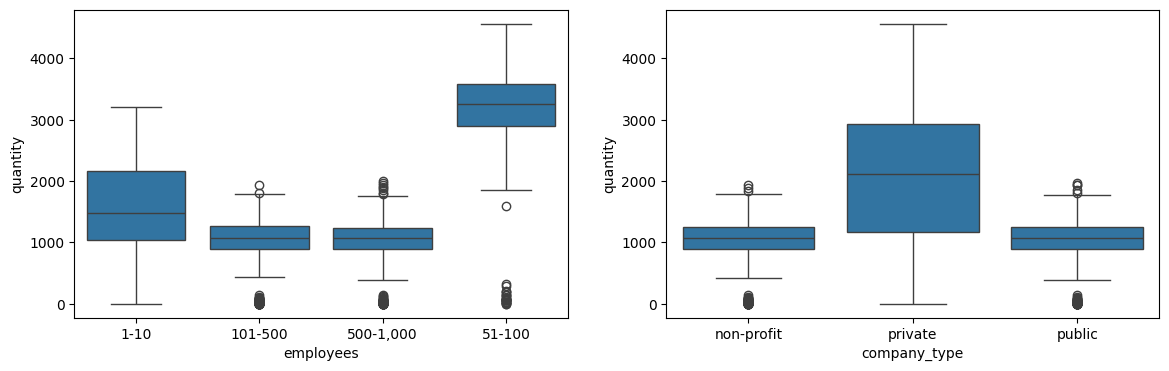

In [30]:
%matplotlib inline
fig, axes = plt.subplots(1,2,figsize=(14,4))

sns.boxplot(
    data = df_agg,
    y = 'quantity',
    x = 'employees',
    ax=axes[0]
)


sns.boxplot(
    data = df_agg,
    y = 'quantity',
    x = 'company_type',
    ax=axes[1]
)

plt.show()

<Axes: xlabel='quantity', ylabel='productcategory'>

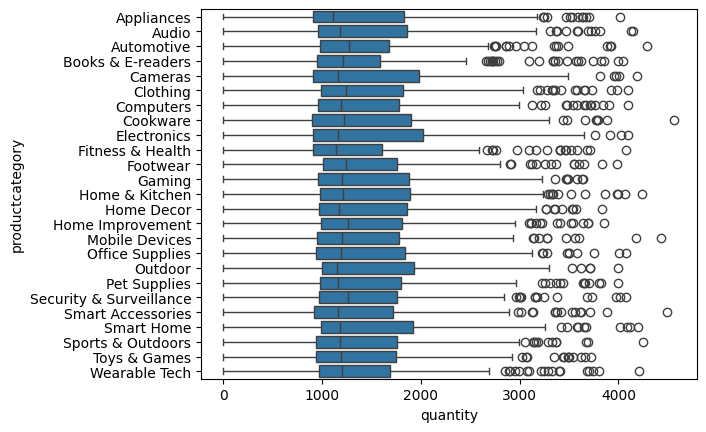

In [31]:
sns.boxplot(
    data = df_agg,
    x = 'quantity',
    y = 'productcategory'
)

<Axes: xlabel='quantity'>

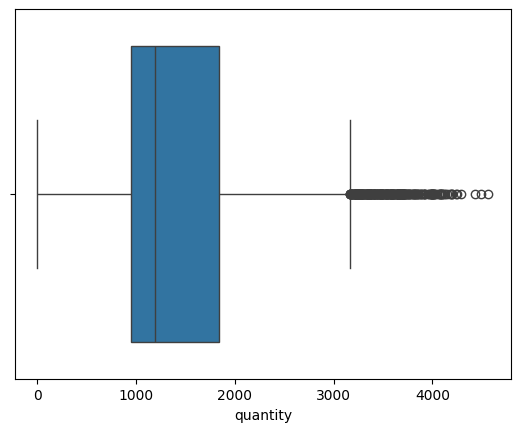

In [32]:
sns.boxplot(
    data = df_agg,
    x = 'quantity'
)

In [33]:
# What are those outliers? What is the percentage of outlier ?

x = np.quantile(df_agg['quantity'], [0, 0.25, 0.5, 0.75, 1])

q1 = x[1]
median = x[2]
q3 = x[3]
iqr = q3 -  q1

df_agg['outlier'] = np.where(
    (df_agg['quantity'] > q3 + 1.5*iqr) |
    (df_agg['quantity'] < q1 - 1.5*iqr),
    1, 0
) 

outliers = df_agg[df_agg['outlier'] == 1]['date'].count()
rows = df_agg['date'].count()

print(f'{outliers} Outliers found --> {outliers/rows * 100} % of total data')

df_agg[df_agg['outlier'] == 1].head(10)

275 Outliers found --> 8.270676691729323 % of total data


,date,productcategory,company_type,employees,quantity,unemployment_rate,gdp_value,mortgage_rate_30y,cpi,outlier
179,2020-02-01,Appliances,private,51-100,3171.0,3.5,21481.367,3.51,257.971,1
186,2020-02-01,Audio,private,51-100,3809.0,3.5,21481.367,3.51,257.971,1
200,2020-02-01,Books & E-readers,private,51-100,4042.0,3.5,21481.367,3.51,257.971,1
207,2020-02-01,Cameras,private,51-100,3297.0,3.5,21481.367,3.51,257.971,1
214,2020-02-01,Clothing,private,51-100,3928.0,3.5,21481.367,3.51,257.971,1
221,2020-02-01,Computers,private,51-100,3258.0,3.5,21481.367,3.51,257.971,1
228,2020-02-01,Cookware,private,51-100,3243.0,3.5,21481.367,3.51,257.971,1
270,2020-02-01,Home Decor,private,51-100,3533.0,3.5,21481.367,3.51,257.971,1
291,2020-02-01,Office Supplies,private,51-100,3229.0,3.5,21481.367,3.51,257.971,1
298,2020-02-01,Outdoor,private,51-100,3616.0,3.5,21481.367,3.51,257.971,1


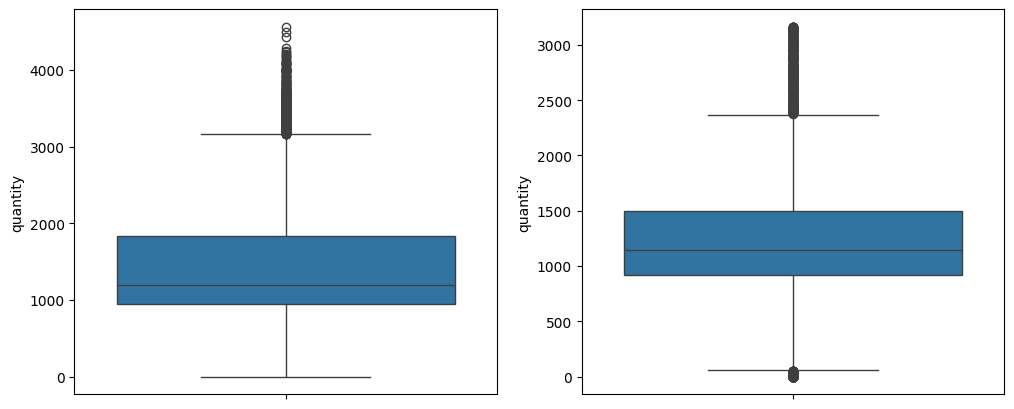

In [40]:
# If we remove outliers then we are removing times so in this case is better to replace them or keep them

fig, axes = plt.subplots(1,2,figsize=(12,5))
sns.boxplot(
    data = df_agg,
    y = 'quantity',
    ax=axes[0]
)
sns.boxplot(
    data = df_agg[df_agg['outlier']==0],
    y = 'quantity',
    ax=axes[1]
)

df_agg.drop(
    'outlier',
    axis=1,
    inplace=True
)

### Check correlations

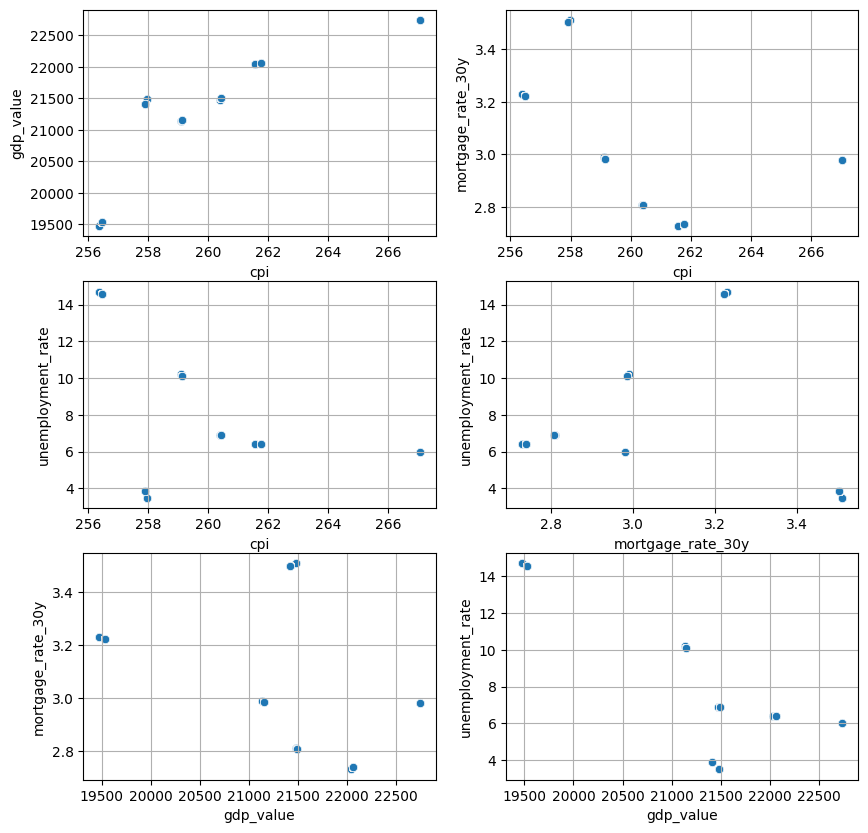

In [43]:
## Correlations between economic variables

fig, axes = plt.subplots(3, 2, figsize=(10, 10))
axes = axes.ravel()

sns.scatterplot(
    data=df_agg,
    x='cpi',
    y='gdp_value',
    ax=axes[0]
)

sns.scatterplot(
    data=df_agg,
    x='cpi',
    y='mortgage_rate_30y',
    ax=axes[1]
)

sns.scatterplot(
    data=df_agg,
    x='cpi',
    y='unemployment_rate',
    ax=axes[2]
)

sns.scatterplot(
    data=df_agg,
    x='mortgage_rate_30y',
    y='unemployment_rate',
    ax=axes[3]
)

sns.scatterplot(
    data=df_agg,
    x='gdp_value',
    y='mortgage_rate_30y',
    ax=axes[4]
)

sns.scatterplot(
    data=df_agg,
    x='gdp_value',
    y='unemployment_rate',
    ax=axes[5]
)

for i in range(6):
    axes[i].grid()


plt.show()

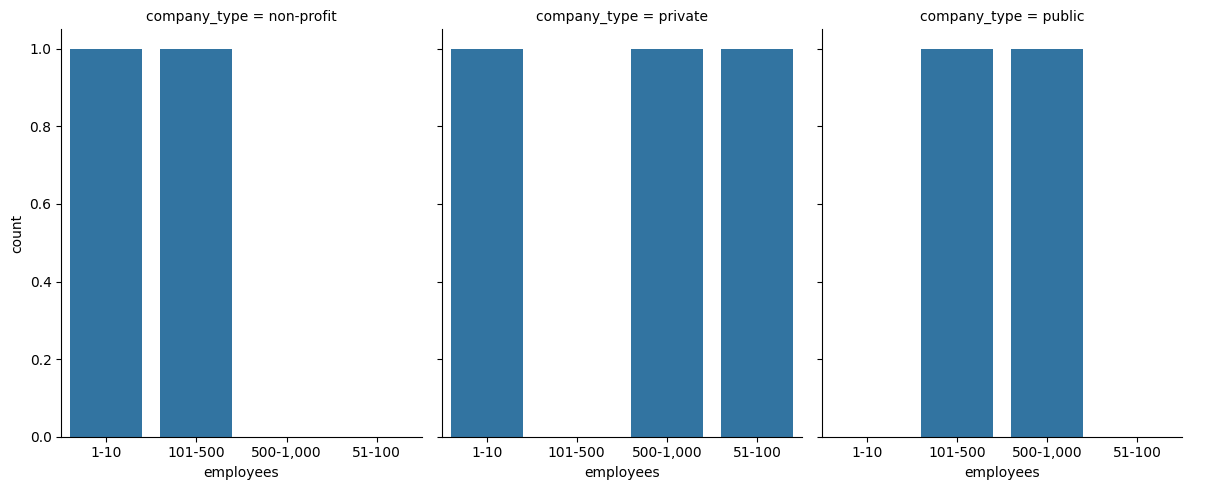

In [44]:
## Correlations between categorical variables
df_comp = df_agg[['company_type', 'employees']].drop_duplicates()

sns.catplot(
    data = df_comp,
    kind = 'count',
    x = 'employees',
    col = 'company_type',
    aspect = .8
)

In [45]:
# Chi-square test to check whether there is a relationship between size and type of the company
# Actually, there is not enough observations here to really make the test.

contingency_table = pd.crosstab(df_comp['company_type'], df_comp['employees'])
chi2, p_val, dof, expected = chi2_contingency(contingency_table)


print("--- Contingency Table ---")
print(contingency_table)
print("\n" + "="*30 + "\n")
print(f"Chi-Square Statistic: {chi2:.4f}")
print(f"p-value: {p_val:.4f}")
print(f"Degrees of Freedom: {dof}")
print("\nExpected Frequencies Table:")
print(expected)
print("\n" + "="*30 + "\n")

--- Contingency Table ---
employees     1-10  101-500  500-1,000  51-100
company_type                                  
non-profit       1        1          0       0
private          1        0          1       1
public           0        1          1       0


Chi-Square Statistic: 4.6667
p-value: 0.5872
Degrees of Freedom: 6

Expected Frequencies Table:
[[0.57142857 0.57142857 0.57142857 0.28571429]
 [0.85714286 0.85714286 0.85714286 0.42857143]
 [0.57142857 0.57142857 0.57142857 0.28571429]]




### Check Autocorrelations

<Axes: xlabel='date'>

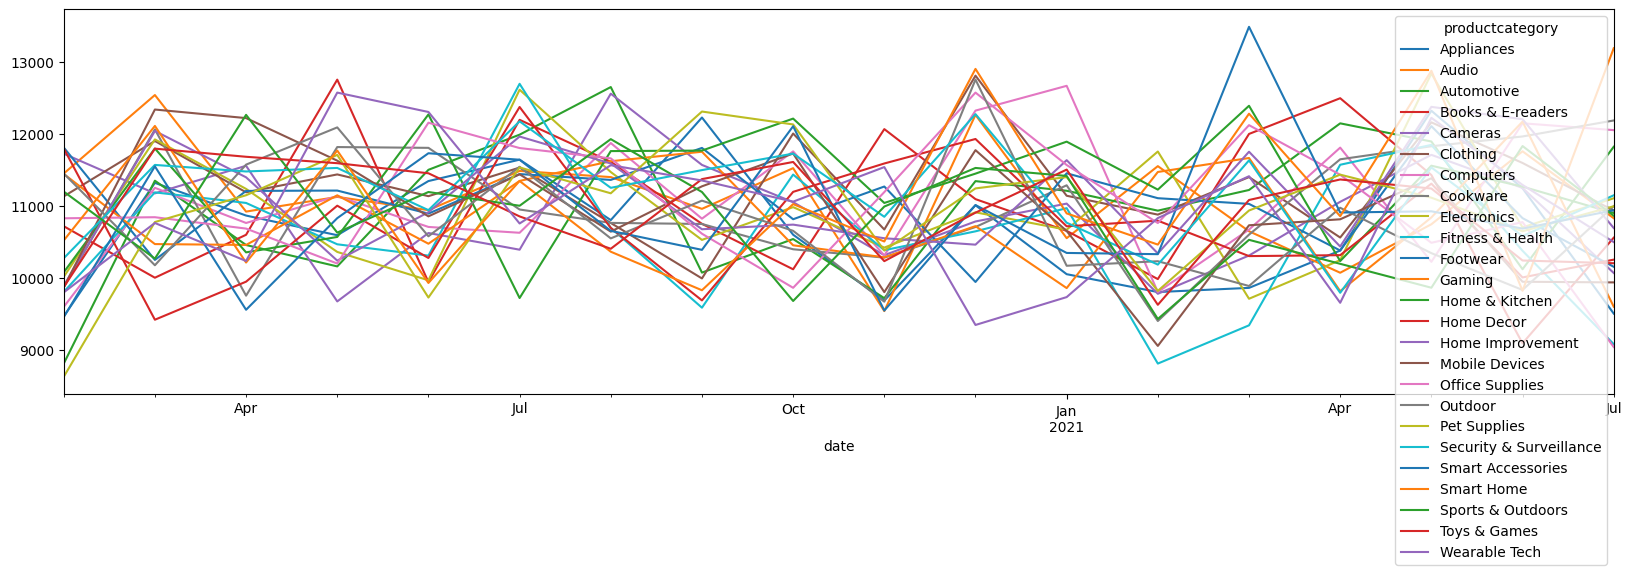

In [47]:

df_ts_products = df_agg.groupby(
    ['date', 'productcategory'],
    as_index=False
).agg(
    {
        'quantity':'sum'
    }
)

df_ts_products = df_ts_products.pivot_table(
    index = 'date',
    columns = 'productcategory',
    values = 'quantity'
).fillna(0)


df_ts_products['2020-02-01':].plot(figsize=(20, 5))

<Axes: xlabel='date'>

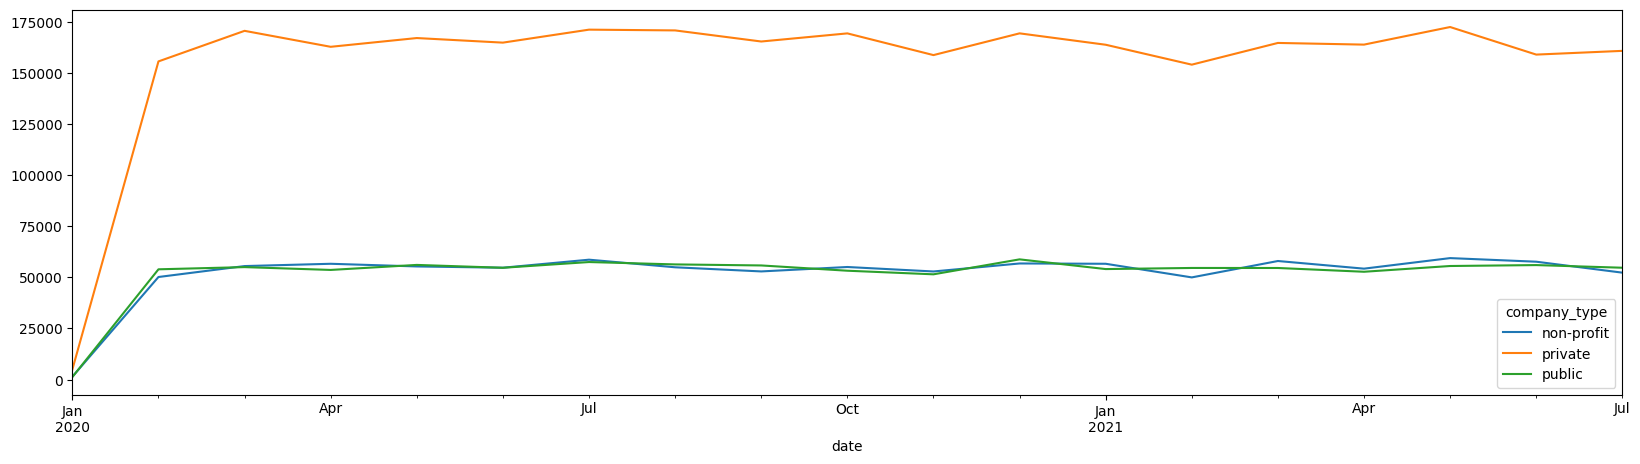

In [48]:
df_ts_company_types = df_agg.groupby(
    ['date', 'company_type'],
    as_index=False
).agg(
    {
        'quantity':'sum'
    }
)


df_ts_company_types = df_ts_company_types.pivot_table(
    index = 'date',
    columns = 'company_type',
    values = 'quantity'
).fillna(0)

df_ts_company_types.plot(figsize=(20, 5))

<Axes: xlabel='date'>

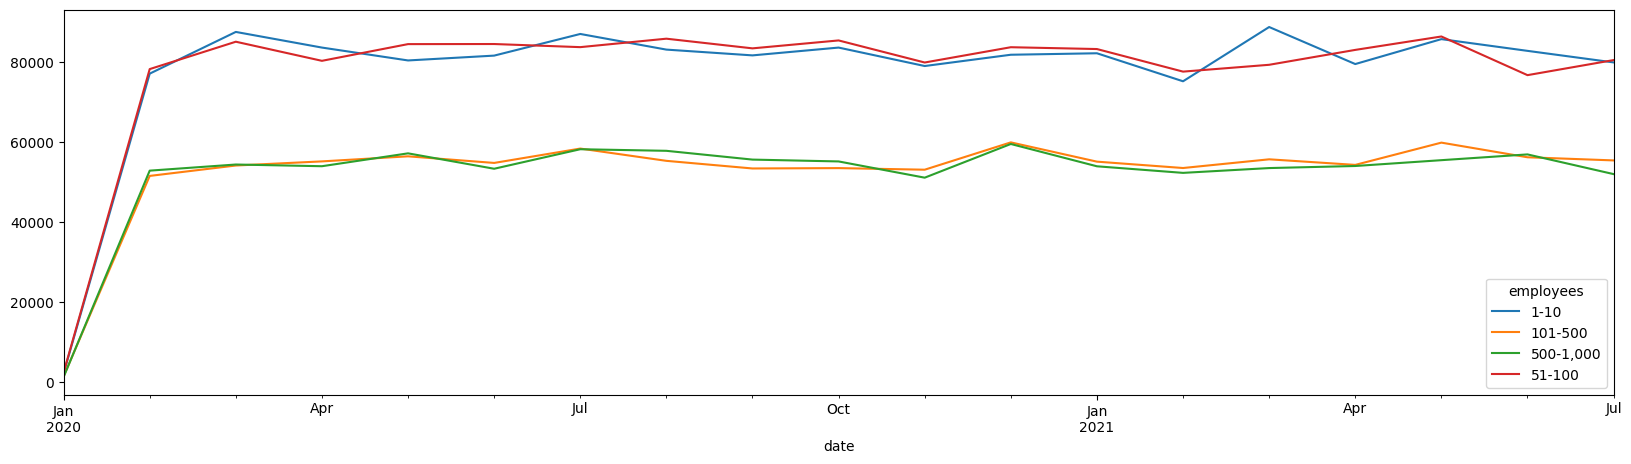

In [49]:
df_ts_employees = df_agg.groupby(
    ['date', 'employees'],
    as_index=False
).agg(
    {
        'quantity':'sum'
    }
)

df_ts_employees = df_ts_employees.pivot_table(
    index = 'date',
    columns = 'employees',
    values = 'quantity'
).fillna(0)

df_ts_employees.plot(figsize=(20, 5))

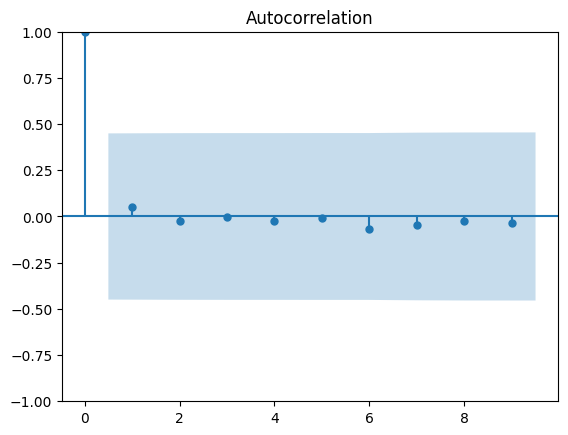

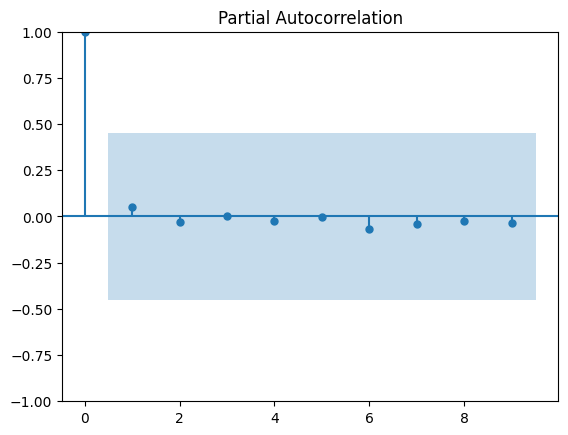

In [50]:
df_acf_pacf = df_agg.groupby(
    'date'
).agg(
    {
        'quantity':'sum'
    }
)

plot_acf(df_acf_pacf)
plot_pacf(df_acf_pacf)
plt.show()

### Take values from 01-02-2020 and Create target variable

In [61]:
# Take values from 01-02-2020

df_f = df_agg[df_agg['date'] >= '2020-02-01']
df_f.head()

,date,productcategory,company_type,employees,quantity,unemployment_rate,gdp_value,mortgage_rate_30y,cpi
175,2020-02-01,Appliances,non-profit,1-10,889.0,3.5,21481.367,3.51,257.971
176,2020-02-01,Appliances,non-profit,101-500,648.0,3.5,21481.367,3.51,257.971
177,2020-02-01,Appliances,private,1-10,1862.0,3.5,21481.367,3.51,257.971
178,2020-02-01,Appliances,private,"500-1,000",785.0,3.5,21481.367,3.51,257.971
179,2020-02-01,Appliances,private,51-100,3171.0,3.5,21481.367,3.51,257.971


In [62]:
# We first set up target value as the next day
df_f["quantity_shifted"] = (
    df_f.sort_values(["company_type", "employees", "productcategory", "date"], 
                      ascending=[True, True, True, True])
      .groupby(["company_type", "employees", "productcategory"])["quantity"]
      .shift(-1)
)

df_f = df_f.fillna(0)

df_f.sort_values(["company_type", "employees", "productcategory", "date"]).head(20)

,date,productcategory,company_type,employees,quantity,unemployment_rate,gdp_value,mortgage_rate_30y,cpi,quantity_shifted
175,2020-02-01,Appliances,non-profit,1-10,889.0,3.500000,21481.367000,3.510000,257.971000,610.0
350,2020-03-01,Appliances,non-profit,1-10,610.0,3.500000,21481.367000,3.510000,257.971000,1033.0
525,2020-04-01,Appliances,non-profit,1-10,1033.0,3.873333,21414.569567,3.500667,257.918267,912.0
700,2020-05-01,Appliances,non-profit,1-10,912.0,14.700000,19477.444000,3.230000,256.389000,981.0
875,2020-06-01,Appliances,non-profit,1-10,981.0,14.700000,19477.444000,3.230000,256.389000,883.0
1050,2020-07-01,Appliances,non-profit,1-10,883.0,14.554839,19531.028839,3.222258,256.476484,1153.0
1225,2020-08-01,Appliances,non-profit,1-10,1153.0,10.200000,21138.574000,2.990000,259.101000,1889.0
1400,2020-09-01,Appliances,non-profit,1-10,1889.0,10.200000,21138.574000,2.990000,259.101000,1318.0
1575,2020-10-01,Appliances,non-profit,1-10,1318.0,10.093548,21149.510226,2.984194,259.142516,1092.0
1750,2020-11-01,Appliances,non-profit,1-10,1092.0,6.900000,21477.597000,2.810000,260.388000,906.0


### Make another profiling analysis

In [63]:
profile = ProfileReport(df_f, title='Purchasing Analysis Prep')
profile.to_file(
    os.path.join(BASE_PATH, 'silver', 'purchase_analysis_prep.html')
)

Export report to file: 100%|██████████| 1/1 [00:00<00:00, 78.08it/s]


### Save Data

In [64]:
df_f.to_csv(os.path.abspath('../data/silver/joined_purchases_prep.csv'), index=False)